This notebook provides tools to pre-generate and cache training datasets for GNN-based quantum error correction decoders.

**Benefits of caching:**
- Generate once, train many times
- ~29 min generation → ~10 sec load time
- Reproducible experiments with same data
- Can run generation overnight|

## Setup

In [1]:
import sys
from pathlib import Path

# Detect if running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/Research/QEC/quantum-error-correction/quantum-error-correction/code')
else:
    BASE_PATH = Path('..')

sys.path.insert(0, str(BASE_PATH))

import torch
from models import DatasetCache, visualize_sparse_graph

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Base path: {BASE_PATH}")
print(f"Datasets directory: {BASE_PATH / 'datasets'}")

Using device: cuda
Base path: ..
Datasets directory: ..\datasets


## List Existing Datasets

View all cached datasets and their configurations.

In [2]:
# List all cached datasets
datasets = DatasetCache.list_datasets(base_path=BASE_PATH)

if not datasets:
    print("No cached datasets found.")
    print(f"Run the generation cells below to create some!")
else:
    print(f"Found {len(datasets)} cached dataset(s):\n")
    for ds in datasets:
        print(f"📁 {ds['name']}")
        print(f"   Samples: {ds.get('n_samples', 'unknown'):,}")
        print(f"   Distance: d={ds.get('d', '?')}")
        print(f"   Error rates: {ds.get('p_values', '?')}")
        print(f"   Size: {ds.get('size_mb', 0):.1f} MB")
        print()

Found 1 cached dataset(s):

📁 d3_baseline
   Samples: 1,000,000
   Distance: d=3
   Error rates: [0.001, 0.003, 0.005, 0.007]
   Size: 1039.8 MB



## Generate New Datasets

Configure and generate training datasets. These will be cached to disk for fast loading during training.

In [10]:
# ============================================================
# CONFIGURATION: Define which datasets to generate
# ============================================================

# Standard error rates used across all datasets
STANDARD_P_VALUES = [0.001, 0.003, 0.005, 0.007]
STANDARD_P_WEIGHTS = [0.25, 0.25, 0.25, 0.25]  # Equal distribution

# Define datasets to generate
# Each entry: (name, distance, n_samples)
DATASETS_TO_GENERATE = [
    ("d3_baseline", 3, 1_000_000),
    # ("d5_baseline", 5, 1_000_000),
    # ("d7_baseline", 7, 1_000_000),
    # ("d9_baseline", 9, 1_000_000),
    # ("d11_baseline", 11, 1_000_000),
    # ("d13_baseline", 13, 1_000_000),
]

# K-neighbors for graph construction
K_NEIGHBORS = 6

print("Datasets configured for generation:")
print(f"  Error rates: {STANDARD_P_VALUES}")
print(f"  Weights: {STANDARD_P_WEIGHTS}")
print(f"  K-neighbors: {K_NEIGHBORS}")
print()
for name, d, n in DATASETS_TO_GENERATE:
    print(f"  • {name}: d={d}, n={n:,}")

Datasets configured for generation:
  Error rates: [0.001, 0.003, 0.005, 0.007]
  Weights: [0.25, 0.25, 0.25, 0.25]
  K-neighbors: 6

  • d3_baseline: d=3, n=1,000,000


In [11]:
# ============================================================
# GENERATE DATASETS
# ============================================================
# This cell will generate all configured datasets.
# Skip any that already exist.

datasets_dir = BASE_PATH / "datasets"

for name, d, n_samples in DATASETS_TO_GENERATE:
    # Check if dataset already exists
    if (datasets_dir / f"{name}.pt").exists():
        print(f"⏭️  Dataset '{name}' already exists, skipping...")
        continue

    print(f"\n{'='*60}")
    print(f"Generating dataset: {name}")
    print(f"{'='*60}")

    # Create and generate dataset
    cache = DatasetCache(base_path=BASE_PATH, device=device)
    cache.generate(
        d=d,
        n_samples=n_samples,
        p_values=STANDARD_P_VALUES,
        p_weights=STANDARD_P_WEIGHTS,
        k_neighbors=K_NEIGHBORS,
        verbose=True
    )

    # Save to disk
    cache.save(name)

    print(f"✅ Dataset '{name}' saved successfully!")

print(f"\n{'='*60}")
print("Generation complete!")
print(f"{'='*60}")


Generating dataset: d3_baseline

Generating dataset: d=3, n_samples=1,000,000
Error rates: [0.001, 0.003, 0.005, 0.007] (weights: [0.25, 0.25, 0.25, 0.25])
SurfaceCodeSampler initialized:
  Default error rate: 0.001
  Device: cuda
  Mode: Dynamic (supports any code distance)
SparseGraph initialized:
  K neighbors: 6
  Device: cuda
  Mode: Dynamic (supports any code distance)

Sampling 1,000,000 detection events...
Converting to PyG graphs...


Converting: 100%|██████████| 1000000/1000000 [09:09<00:00, 1820.14graph/s]



Generated 1,000,000 graphs
Array dataset saved: ..\nn_datasets\d3_baseline_array.pt
Graph dataset saved: ..\datasets\d3_baseline.pt
  Metadata: ..\datasets\d3_baseline.json
  Samples: 1,000,000
✅ Dataset 'd3_baseline' saved successfully!

Generation complete!


## Load and Inspect a Dataset

Load a specific dataset to verify its contents.

In [3]:
# Load a specific dataset for inspection
DATASET_TO_INSPECT = "d3_baseline"  # Change this to inspect different datasets

try:
    cache = DatasetCache(base_path=BASE_PATH, device=device)
    cache.load(DATASET_TO_INSPECT)

    print(f"\nDataset: {DATASET_TO_INSPECT}")
    print(f"Total samples: {len(cache):,}")
    print(f"\nConfiguration:")
    for key, value in cache.config.items():
        print(f"  {key}: {value}")

    # Sample a few graphs
    graphs = cache.get_graphs(n=5)
    print(f"\nSample graph statistics:")
    for i, g in enumerate(graphs):
        print(f"  Graph {i}: {g.x.shape[0]} nodes, {g.edge_index.shape[1]} edges, label={g.y.item():.0f}")

except FileNotFoundError:
    print(f"Dataset '{DATASET_TO_INSPECT}' not found.")
    print("Generate it first using the cells above.")

Loading dataset 'd3_baseline' (1.02 GB)...
  Reading d3_baseline.pt (this may take a while for large files)...
  Loaded 1,000,000 graphs
  Distance: d=3
  Error rates: [0.001, 0.003, 0.005, 0.007]

Dataset: d3_baseline
Total samples: 1,000,000

Configuration:
  d: 3
  n_samples: 1000000
  p_values: [0.001, 0.003, 0.005, 0.007]
  p_weights: [0.25, 0.25, 0.25, 0.25]
  k_neighbors: 6
  generated_at: 2026-01-31T20:12:28.059915

Sample graph statistics:
  Graph 0: 0 nodes, 0 edges, label=0
  Graph 1: 0 nodes, 0 edges, label=0
  Graph 2: 9 nodes, 54 edges, label=1
  Graph 3: 0 nodes, 0 edges, label=0
  Graph 4: 0 nodes, 0 edges, label=0


Searching for 10 non-empty graphs to visualize...

Graph 2: 9 nodes, 54 edges
Label: 1 (observable flip)
Edge width:  4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0


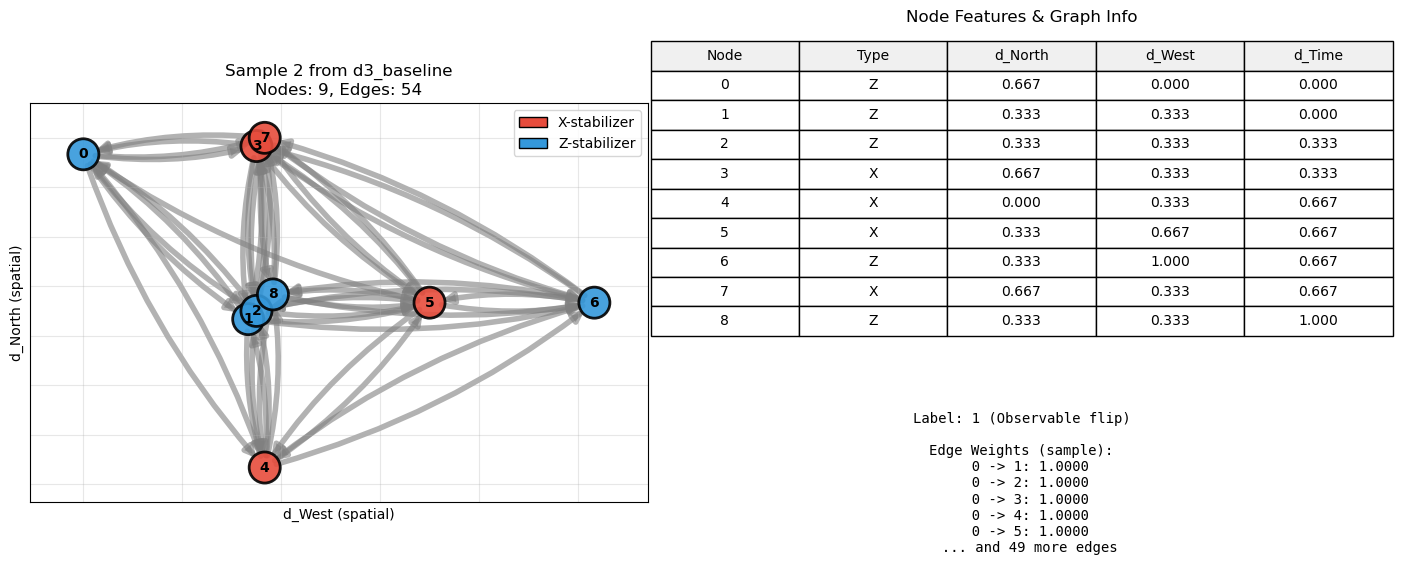

Graph 6: 2 nodes, 2 edges
Label: 0 (observable flip)
Edge width:  4.0 4.0


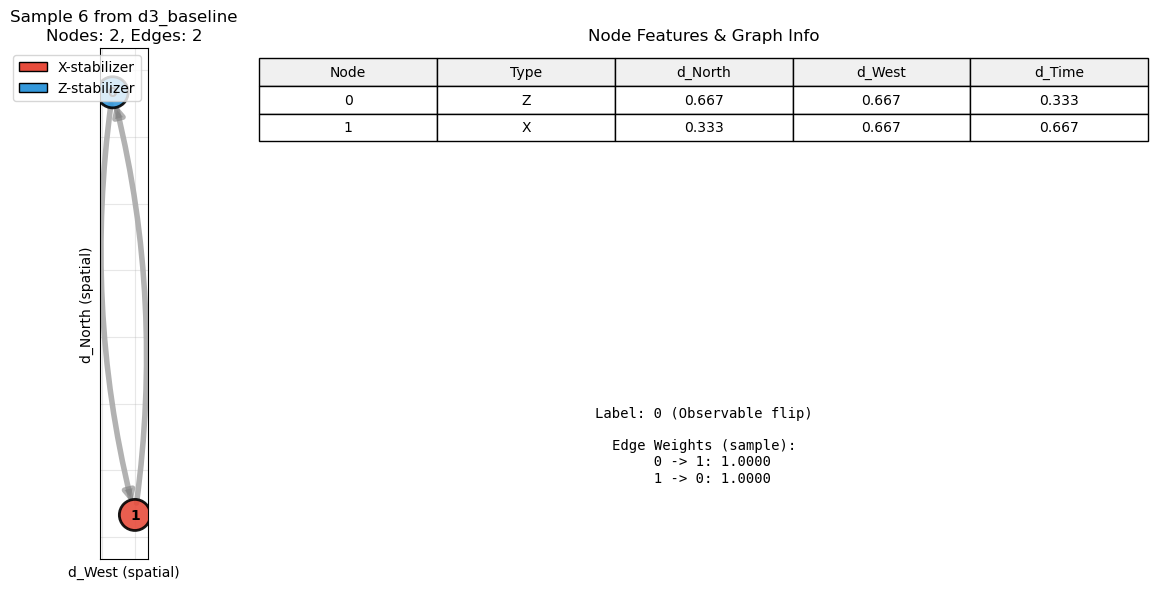

Graph 9: 1 nodes, 0 edges
Label: 0 (observable flip)
Edge width: 


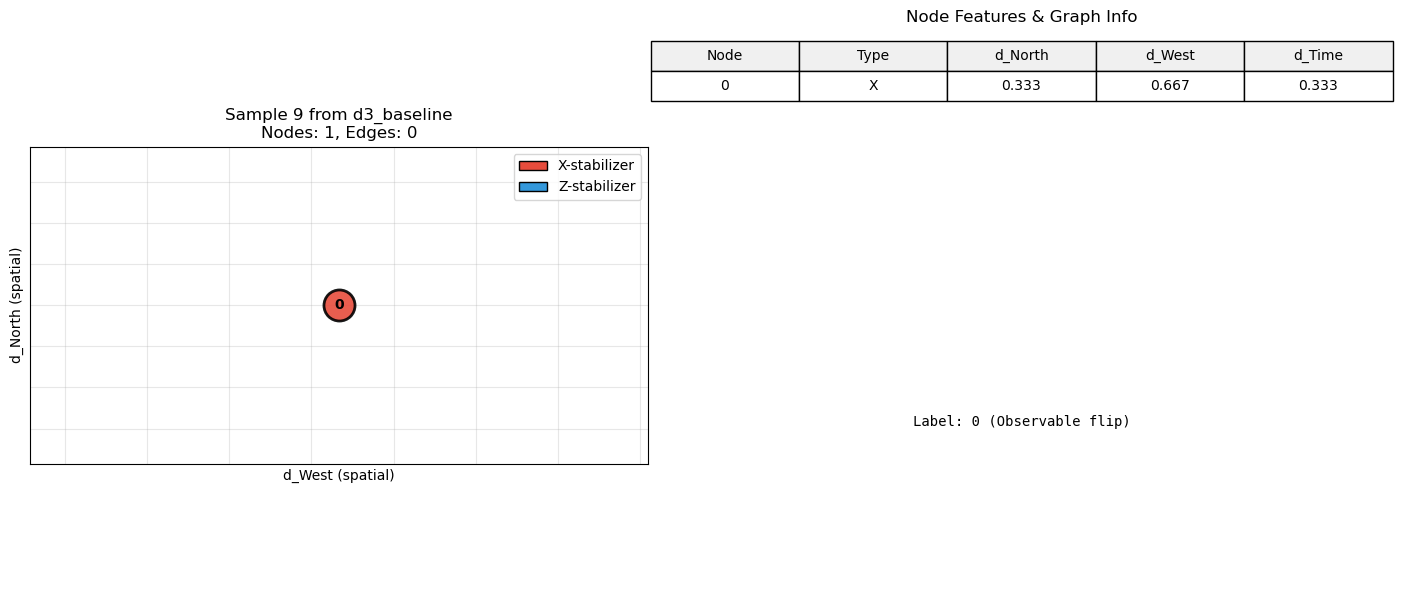

Graph 13: 2 nodes, 2 edges
Label: 0 (observable flip)
Edge width:  4.0 4.0


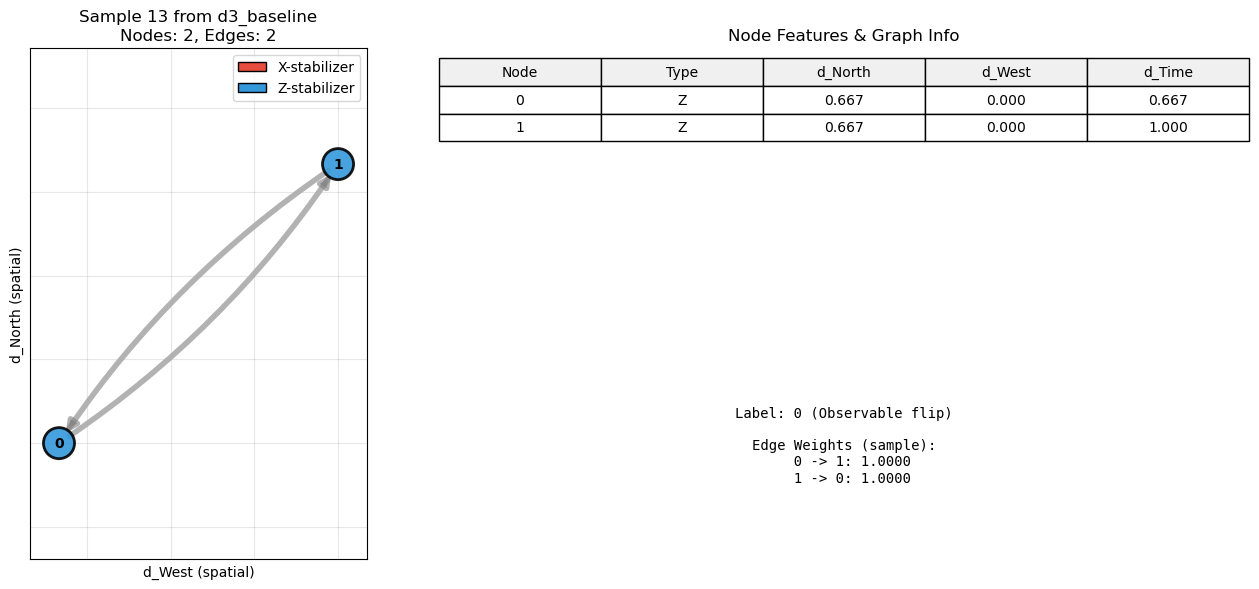

Graph 14: 1 nodes, 0 edges
Label: 0 (observable flip)
Edge width: 


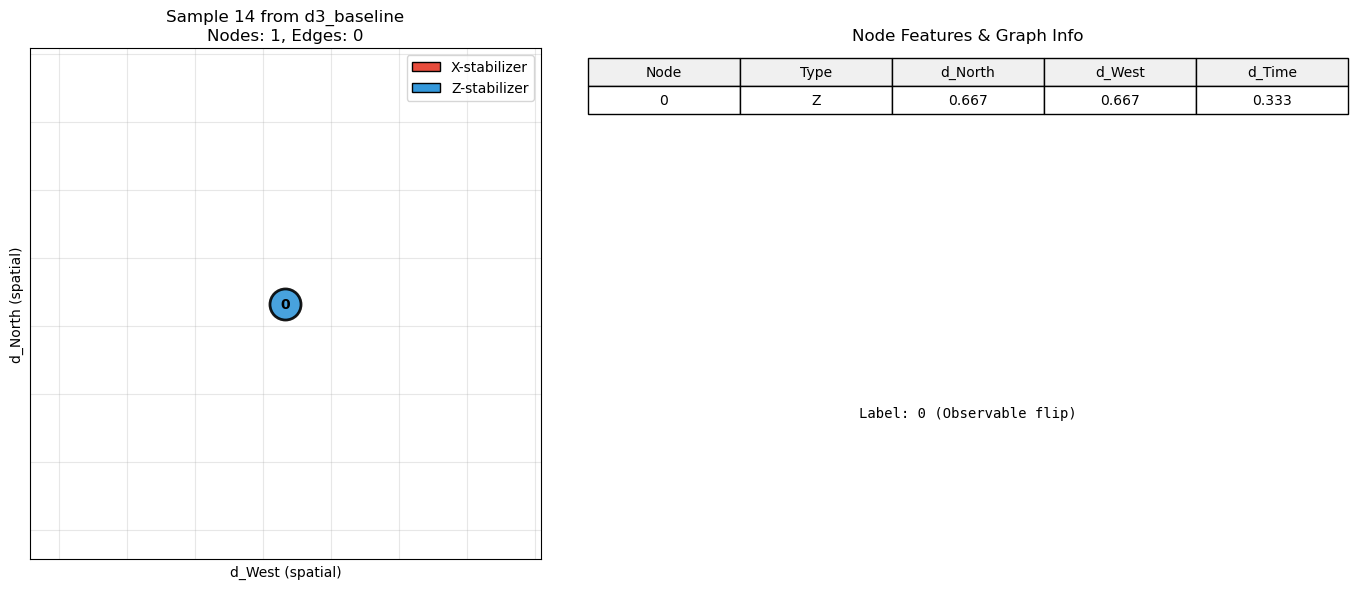

Graph 15: 1 nodes, 0 edges
Label: 0 (observable flip)
Edge width: 


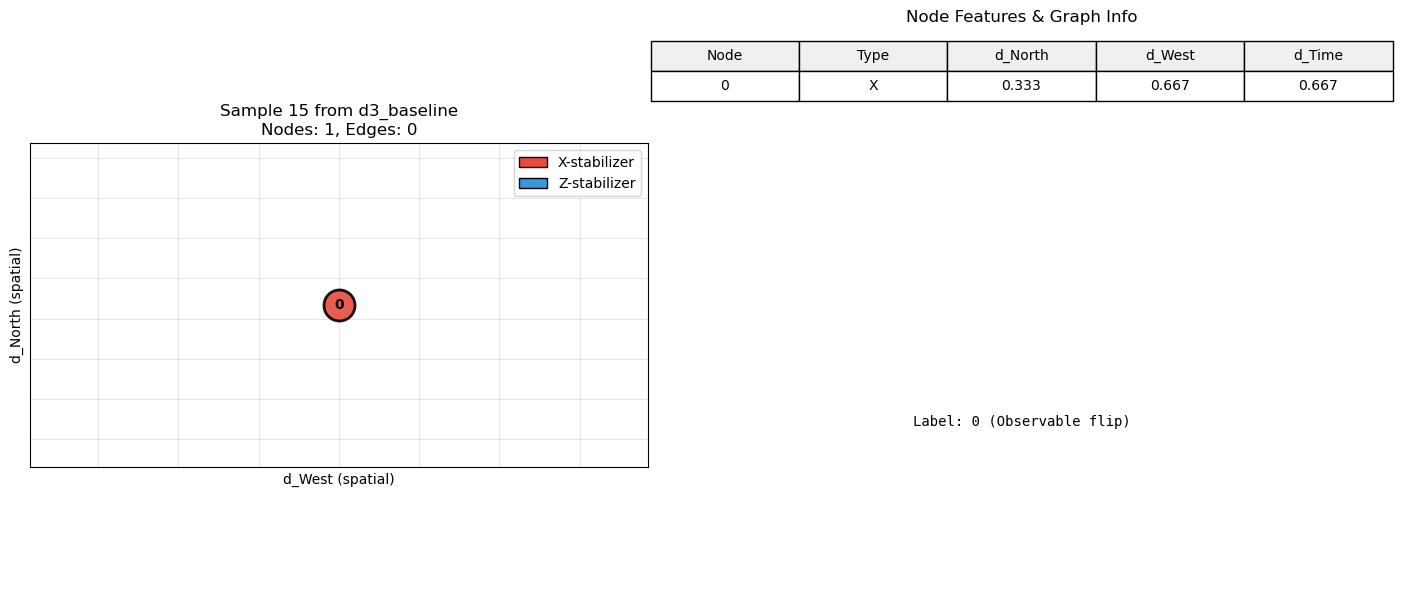

Graph 16: 3 nodes, 6 edges
Label: 0 (observable flip)
Edge width:  4.0 4.0 4.0 4.0 4.0 4.0


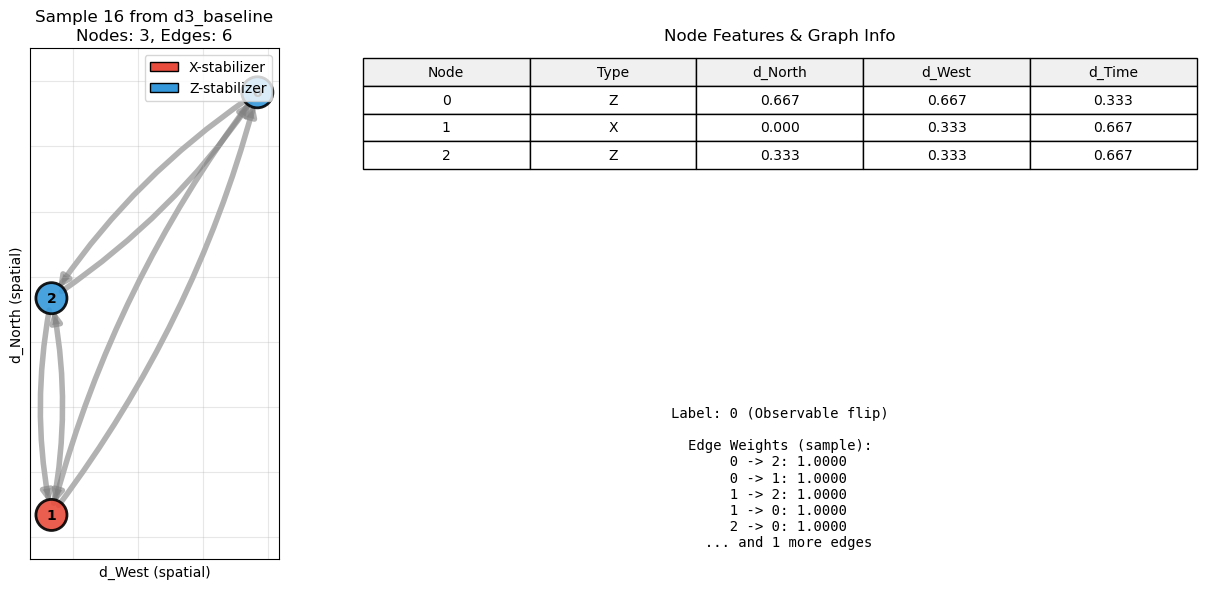

Graph 17: 7 nodes, 42 edges
Label: 1 (observable flip)
Edge width:  4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0


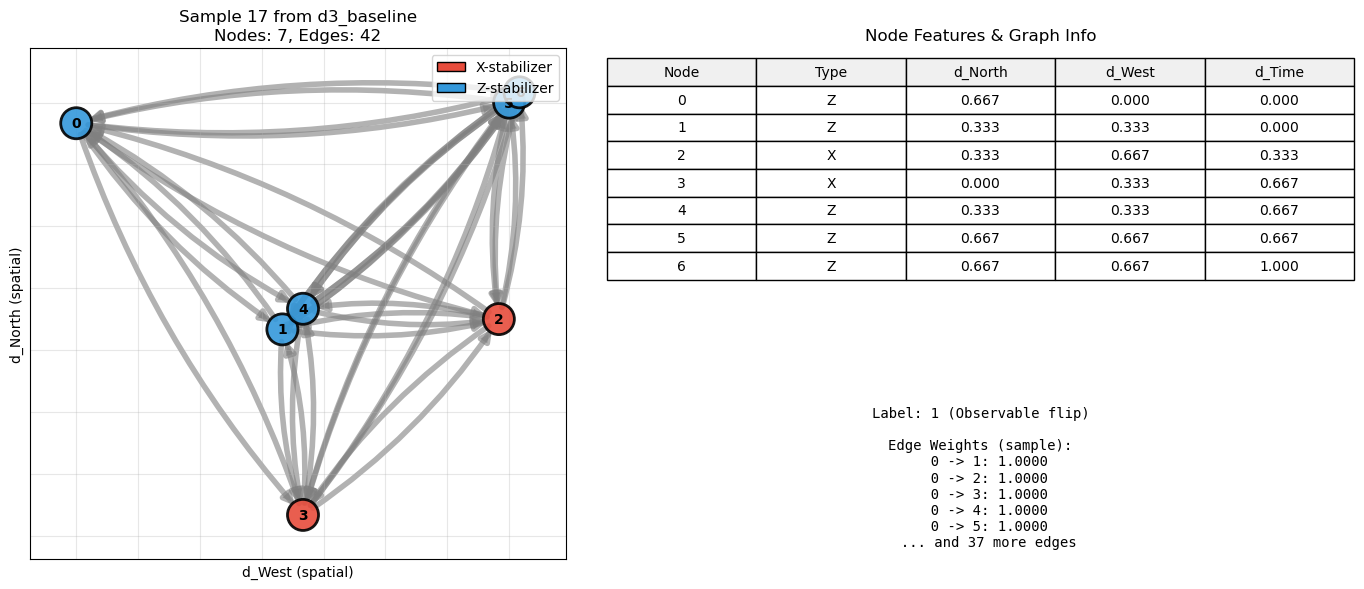

Graph 20: 6 nodes, 30 edges
Label: 0 (observable flip)
Edge width:  4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0 4.0


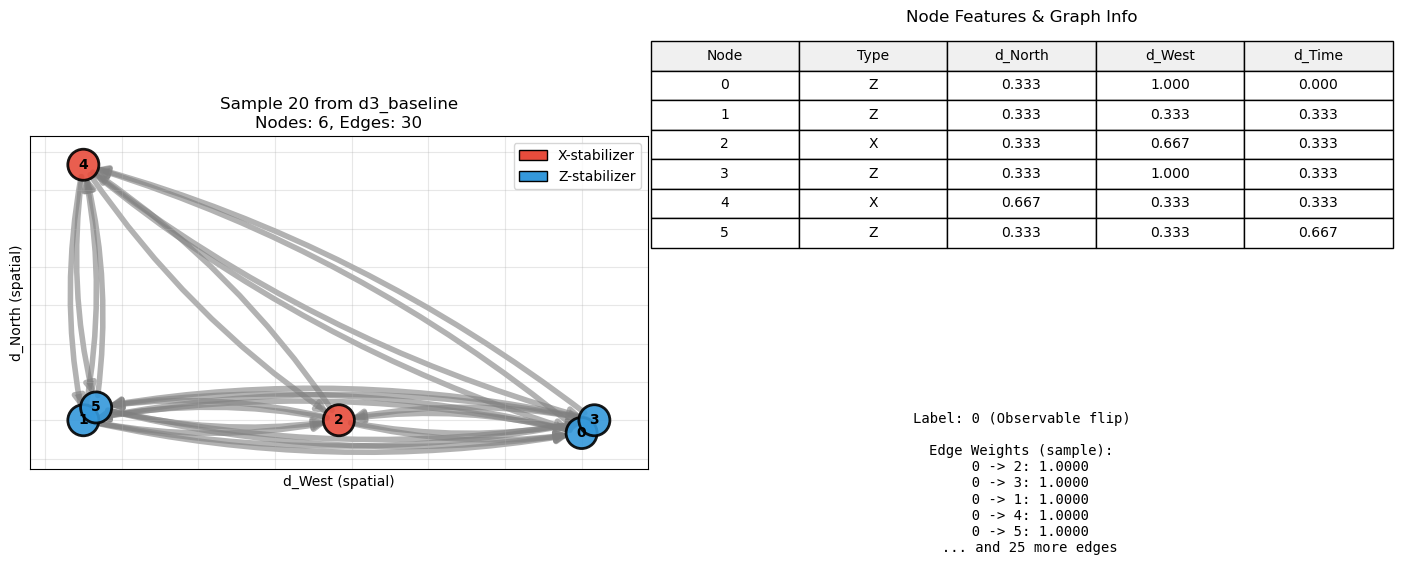

Graph 22: 1 nodes, 0 edges
Label: 0 (observable flip)
Edge width: 


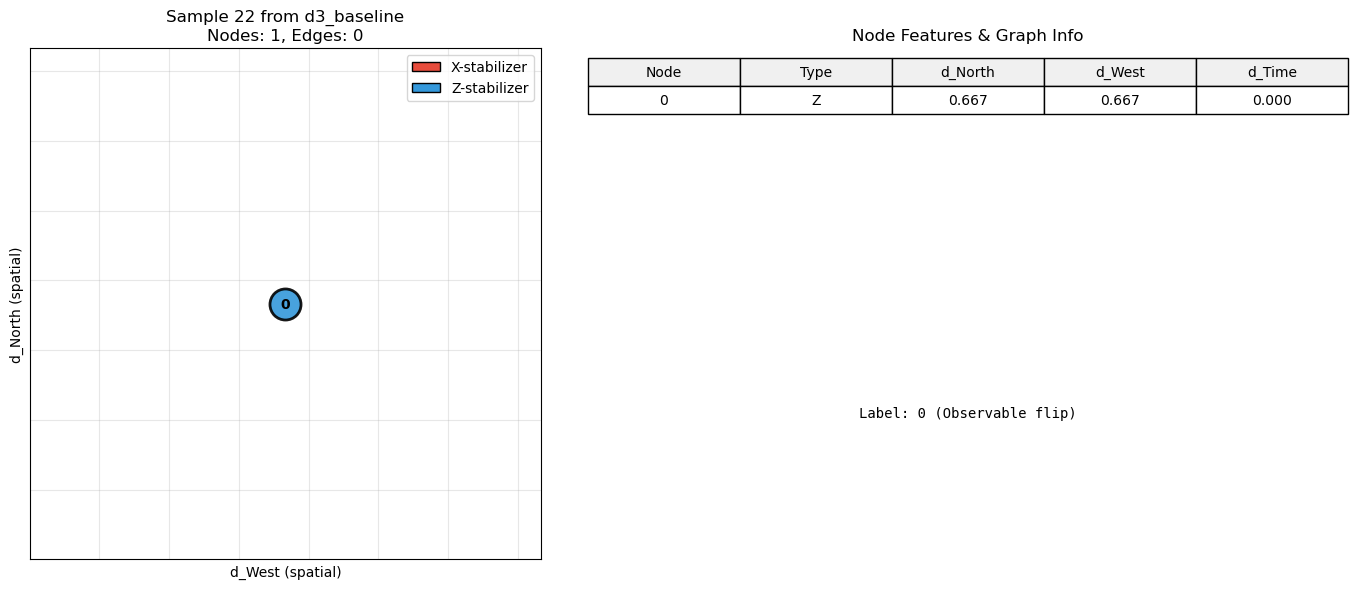

In [4]:
# Visualize sample graphs from the dataset
# Find non-empty graphs (graphs with fired detectors) for visualization

NUM_GRAPHS_TO_SHOW = 10  # Number of graphs to visualize

print(f"Searching for {NUM_GRAPHS_TO_SHOW} non-empty graphs to visualize...\n")

graphs_shown = 0
for i, g in enumerate(cache.get_graphs()):
    # Only visualize graphs that have nodes (fired detectors)
    if g.x.shape[0] > 0 and graphs_shown < NUM_GRAPHS_TO_SHOW:
        print(f"{'='*60}")
        print(f"Graph {i}: {g.x.shape[0]} nodes, {g.edge_index.shape[1]} edges")
        print(f"Label: {g.y.item():.0f} (observable flip)")
        print(f"{'='*60}")

        visualize_sparse_graph(g, title=f"Sample {i} from {DATASET_TO_INSPECT}")
        graphs_shown += 1

    # Stop after showing enough graphs
    if graphs_shown >= NUM_GRAPHS_TO_SHOW:
        break

if graphs_shown == 0:
    print("No non-empty graphs found in the first samples.")

## Convert Graph Datasets to Array Format (Legacy)

**Note:** As of January 2026, `DatasetCache.save()` automatically saves both graph and array formats. This section is only needed for datasets generated before this change.

---

Reverse engineer the original detection arrays from cached PyG graph datasets. This creates compact array-based datasets that are faster to load and smaller on disk.

**Benefits of array format:**
- Much smaller file sizes (no edge data)
- Faster loading times
- Useful for non-GNN models or custom graph construction

In [14]:
from models import SparseGraph
from tqdm import tqdm
import json

def reverse_engineer_detections(graphs: list, d: int, k_neighbors: int = 6, verbose: bool = True):
    """
    Reverse engineer detection arrays from PyG graph datasets.

    The graph nodes contain feature vectors [is_x, is_z, d_north, d_west, d_time]
    which are deterministically computed from detector indices. By matching these
    features back to the original detector positions, we can reconstruct the
    full detection array.

    Args:
        graphs: List of PyG Data objects
        d: Code distance
        k_neighbors: K-neighbors used in graph construction (for feature computation)
        verbose: Print progress information

    Returns:
        tuple: (detections, labels) where:
            - detections: Tensor of shape [n_samples, num_detectors] with values -1 or +1
            - labels: Tensor of shape [n_samples] with values 0 or 1
    """
    # Compute number of detectors for this distance
    num_detectors = (d**2 - 1) * d

    if verbose:
        print(f"Reverse engineering detections for d={d}")
        print(f"  Number of detectors: {num_detectors}")
        print(f"  Number of graphs: {len(graphs):,}")

    # Build feature lookup table using SparseGraph
    # Note: SparseGraph infers distance from num_detectors, doesn't need d parameter
    graph_builder = SparseGraph(k_neighbors=k_neighbors)
    _, all_features, _, _ = graph_builder._get_coords_and_features(num_detectors)

    # Pre-allocate output tensors
    all_detections = torch.full((len(graphs), num_detectors), -1, dtype=torch.float32)
    all_labels = torch.zeros(len(graphs), dtype=torch.long)

    # Process each graph
    iterator = tqdm(enumerate(graphs), total=len(graphs), desc="Reverse engineering") if verbose else enumerate(graphs)

    for i, graph in iterator:
        # Store label
        all_labels[i] = graph.y.item() if graph.y.numel() == 1 else graph.y[0].item()

        # Skip empty graphs (no fired detectors)
        if graph.x.shape[0] == 0:
            continue

        # Match each node's features back to detector index
        for node_feat in graph.x:
            # Compute L1 distance to all detector features
            diffs = (all_features - node_feat).abs().sum(dim=1)
            detector_idx = diffs.argmin().item()
            all_detections[i, detector_idx] = 1.0

    if verbose:
        # Statistics
        fired_counts = (all_detections > 0).sum(dim=1).float()
        print(f"\nStatistics:")
        print(f"  Mean fired detectors per sample: {fired_counts.mean():.2f}")
        print(f"  Max fired detectors: {fired_counts.max():.0f}")
        print(f"  Label distribution: {all_labels.sum().item():,} positive / {len(all_labels):,} total")

    return all_detections, all_labels

In [15]:
# ============================================================
# CONFIGURATION: Which datasets to convert
# ============================================================

# Datasets to convert (name, distance)
DATASETS_TO_CONVERT = [
    # ("d3_baseline", 3),
    # ("d5_baseline", 5),
    # ("d7_baseline", 7),
    # ("d9_baseline", 9),
    # ("d11_baseline", 11),
]

# Output naming convention: {name}_array.pt
# e.g., d3_baseline -> d3_baseline_array.pt

print("Datasets configured for conversion:")
for name, d in DATASETS_TO_CONVERT:
    num_detectors = (d**2 - 1) * d
    print(f"  • {name} (d={d}, {num_detectors} detectors) -> {name}_array.pt")

Datasets configured for conversion:


In [16]:
# ============================================================
# CONVERT DATASETS TO ARRAY FORMAT
# ============================================================

from datetime import datetime
import os
import tempfile
import shutil
import json

# #region agent log - minimal instrumentation for verification
LOG_PATH = r"g:\My Drive\Research\QEC\quantum-error-correction\quantum-error-correction\.cursor\debug.log"
def _log(msg, data=None):
    import time, os as _os; _os.makedirs(_os.path.dirname(LOG_PATH), exist_ok=True)
    entry = {"timestamp": int(time.time()*1000), "message": msg, "data": data or {}}
    with open(LOG_PATH, "a", encoding="utf-8") as f: f.write(json.dumps(entry) + "\n")
# #endregion

# Source: graph datasets
source_dir = BASE_PATH / "datasets"

# Output: array datasets in nn_datasets folder
output_dir = BASE_PATH / "nn_datasets"
output_dir.mkdir(parents=True, exist_ok=True)

for name, d in DATASETS_TO_CONVERT:
    print(f"\n{'='*60}")
    print(f"Converting: {name}")
    print(f"{'='*60}")

    # Check if source exists
    source_path = source_dir / f"{name}.pt"
    if not source_path.exists():
        print(f"  ⚠️ Source not found: {source_path}")
        print(f"  Skipping...")
        continue

    # Check if already converted
    output_path = output_dir / f"{name}_array.pt"
    if output_path.exists():
        print(f"  ✓ Already converted: {output_path}")
        print(f"  Skipping (delete file to reconvert)")
        continue

    # Load source dataset
    print(f"  Loading graphs from {source_path}...")
    start_time = datetime.now()

    cache = DatasetCache(base_path=BASE_PATH)
    cache.load(name, verbose=False)

    load_time = (datetime.now() - start_time).total_seconds()
    print(f"  Loaded {len(cache.graphs):,} graphs in {load_time:.1f}s")

    # Reverse engineer detections
    detections, labels = reverse_engineer_detections(
        cache.graphs,
        d=d,
        k_neighbors=cache.config.get('k_neighbors', 6),
        verbose=True
    )

    # Free memory from graphs
    del cache.graphs

    # Save array format
    print(f"\n  Saving to {output_path}...")
    save_data = {
        'detections': detections,
        'labels': labels,
        'd': d,
        'n_samples': len(labels),
        'num_detectors': detections.shape[1],
        'converted_from': name,
        'converted_at': datetime.now().isoformat(),
    }

    # #region agent log - Fix: Write to local temp file first to avoid Google Drive sync conflicts
    _log("save_start", {"output_path": str(output_path)})
    temp_path = None
    try:
        # Create temp file on local disk (not cloud synced)
        with tempfile.NamedTemporaryFile(delete=False, suffix='.pt') as tmp:
            temp_path = tmp.name
        _log("temp_file_created", {"temp_path": temp_path})

        # Save to local temp file (bypasses Google Drive interference)
        torch.save(save_data, temp_path)
        _log("temp_save_success", {"size_bytes": os.path.getsize(temp_path)})

        # Move to final Google Drive location (atomic operation)
        shutil.move(temp_path, output_path)
        _log("move_success", {"final_path": str(output_path)})
    except Exception as e:
        _log("save_error", {"error": str(e), "error_type": type(e).__name__, "temp_path": temp_path})
        if temp_path and os.path.exists(temp_path):
            os.remove(temp_path)
        raise
    # #endregion

    # Report size comparison
    source_size_mb = os.path.getsize(source_path) / (1024 * 1024)
    output_size_mb = os.path.getsize(output_path) / (1024 * 1024)
    reduction = (1 - output_size_mb / source_size_mb) * 100

    print(f"\n  ✓ Saved successfully!")
    print(f"  Size: {source_size_mb:.1f} MB -> {output_size_mb:.1f} MB ({reduction:.1f}% reduction)")

print(f"\n{'='*60}")
print("Conversion complete!")
print(f"{'='*60}")


Conversion complete!


### Load and Verify Array Datasets

Quick utility to load and inspect the converted array datasets.

In [17]:
# List all array datasets
nn_datasets_dir = BASE_PATH / "nn_datasets"

print("Array format datasets:\n")
for f in sorted(nn_datasets_dir.glob("*_array.pt")):
    data = torch.load(f, weights_only=False)
    size_mb = os.path.getsize(f) / (1024 * 1024)

    print(f"📁 {f.name}")
    print(f"   Distance: d={data['d']}")
    print(f"   Samples: {data['n_samples']:,}")
    print(f"   Detectors: {data['num_detectors']}")
    print(f"   Detections shape: {data['detections'].shape}")
    print(f"   Labels shape: {data['labels'].shape}")
    print(f"   Size: {size_mb:.1f} MB")
    print()

Array format datasets:

📁 d3_baseline_array.pt
   Distance: d=3
   Samples: 1,000,000
   Detectors: 24
   Detections shape: torch.Size([1000000, 24])
   Labels shape: torch.Size([1000000])
   Size: 95.4 MB



### Verify Conversion Correctness

Test that the reverse engineering correctly recovers the original detection arrays by comparing reconstructed graphs with originals.

In [18]:
# ============================================================
# VERIFICATION TEST
# ============================================================
# Tests that converting detection -> graph -> detection gives back the same result

TEST_DATASET = "d3_baseline"  # Small dataset for quick testing
TEST_SAMPLES = 100  # Number of samples to verify

# Array datasets in nn_datasets, graph datasets in datasets
nn_datasets_dir = BASE_PATH / "nn_datasets"
datasets_dir = BASE_PATH / "datasets"
array_path = nn_datasets_dir / f"{TEST_DATASET}_array.pt"
graph_path = datasets_dir / f"{TEST_DATASET}.pt"

if not array_path.exists():
    print(f"Array dataset not found: {array_path}")
    print("Run the conversion cell first!")
elif not graph_path.exists():
    print(f"Graph dataset not found: {graph_path}")
else:
    print(f"Verifying conversion for {TEST_DATASET}...")
    print(f"Testing {TEST_SAMPLES} samples\n")

    # Load both datasets
    array_data = torch.load(array_path, weights_only=False)
    graphs = torch.load(graph_path, weights_only=False)[:TEST_SAMPLES]

    d = array_data['d']
    num_detectors = array_data['num_detectors']

    # Build graph converter
    graph_builder = SparseGraph(k_neighbors=6)
    _, all_features, _, _ = graph_builder._get_coords_and_features(num_detectors)

    errors = 0
    for i in range(TEST_SAMPLES):
        # Get stored detection array
        stored_detections = array_data['detections'][i]
        stored_label = array_data['labels'][i]

        # Get original graph
        original_graph = graphs[i]

        # Reconstruct graph from stored detections
        reconstructed_graph = graph_builder.to_pyg(stored_detections, stored_label)

        # Compare: same number of nodes?
        if original_graph.x.shape[0] != reconstructed_graph.x.shape[0]:
            errors += 1
            print(f"  Sample {i}: Node count mismatch ({original_graph.x.shape[0]} vs {reconstructed_graph.x.shape[0]})")
            continue

        # Compare: same node features (sorted, since order might differ)?
        orig_sorted = original_graph.x[original_graph.x[:, 2].argsort()] if original_graph.x.shape[0] > 0 else original_graph.x
        recon_sorted = reconstructed_graph.x[reconstructed_graph.x[:, 2].argsort()] if reconstructed_graph.x.shape[0] > 0 else reconstructed_graph.x

        if not torch.allclose(orig_sorted, recon_sorted, atol=1e-5):
            errors += 1
            print(f"  Sample {i}: Feature mismatch")
            continue

        # Compare: same label?
        orig_label = original_graph.y.item() if original_graph.y.numel() == 1 else original_graph.y[0].item()
        if orig_label != stored_label.item():
            errors += 1
            print(f"  Sample {i}: Label mismatch ({orig_label} vs {stored_label.item()})")

    if errors == 0:
        print(f"✓ All {TEST_SAMPLES} samples verified successfully!")
        print("  The reverse engineering correctly recovers the original data.")
    else:
        print(f"\n✗ {errors}/{TEST_SAMPLES} samples had errors")

Verifying conversion for d3_baseline...
Testing 100 samples

SparseGraph initialized:
  K neighbors: 6
  Device: cuda
  Mode: Dynamic (supports any code distance)


ValueError: not enough values to unpack (expected 4, got 3)

## Grow Existing Dataset

If you need more samples for an existing dataset, use `ensure_size()` to grow it.

In [ ]:
# Grow an existing dataset to a larger size
# Uncomment and modify to use

# DATASET_TO_GROW = "d3_baseline"
# TARGET_SIZE = 2_000_000  # New target size

# cache = DatasetCache(base_path=BASE_PATH, device=device)
# cache.load(DATASET_TO_GROW)
# cache.ensure_size(TARGET_SIZE)
# cache.save(DATASET_TO_GROW)  # Overwrite with larger dataset

print("Uncomment the code above to grow an existing dataset.")

## Delete a Dataset

Remove a cached dataset from disk.

In [ ]:
# Delete a dataset
# Uncomment and modify to use

# import os
# DATASET_TO_DELETE = "d3_baseline"
#
# datasets_dir = BASE_PATH / "datasets"
# data_path = datasets_dir / f"{DATASET_TO_DELETE}.pt"
# meta_path = datasets_dir / f"{DATASET_TO_DELETE}.json"
#
# if data_path.exists():
#     os.remove(data_path)
#     print(f"Deleted: {data_path}")
# if meta_path.exists():
#     os.remove(meta_path)
#     print(f"Deleted: {meta_path}")

print("Uncomment the code above to delete a dataset.")